In [1]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

from utils import TensorCode_util as tc
import numpy as np
import matplotlib.pyplot as plt
from utils import initvalues_util
import copy
import utils.plot_utils as plot
import keras
import joblib
import shap 
import time

%load_ext autoreload
%autoreload 2

/Users/kabirkumar/miniconda3/envs/thesis/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
num_bodies = 3
equal_masses = True
savefig = False

model_type = 'DT'

In [3]:
sub_name = "_" + str(num_bodies) + "_bodies"

num_pred_steps_to_plot = 3000
trained_model_sub_name = ''

if equal_masses:
    trained_model_sub_name += '_equal_masses'
    sub_name = sub_name + '_equal_masses'
else:
    sub_name = sub_name + ""

dataset_sub_name = ""
if equal_masses:
    dataset_sub_name = dataset_sub_name + "_equal_mass"

In [5]:

if model_type in ['RF', 'DT']:
    trained_model = joblib.load(f'trained_models/{model_type}{trained_model_sub_name}_trained.joblib')
else:
    trained_model = keras.models.load_model(f'trained_models/{model_type}{trained_model_sub_name}_trained.keras')

filepath = f"{model_type}"

In [6]:
all_kepler_data_1 = np.load(f'datasets/kepler_solver/simulated_train_dataset_2_body{dataset_sub_name}.npy')
all_kepler_data_2 = np.load(f'datasets/kepler_solver/simulated_train_dataset_3_body{dataset_sub_name}.npy')
all_kepler_data = np.concatenate((all_kepler_data_1, all_kepler_data_2))

In [7]:
tau, n, m, r, v = initvalues_util.initValues(num_bodies, equal_mass=equal_masses)

In [8]:
r_t = [r]
v_t = [v]

start = time.time()
for k in range(num_pred_steps_to_plot):
    rv = np.column_stack([r, v])
    
    rv1, kepler_data = tc.do_step_wrapper_normal(tau, n, m, rv, gen_kepler_data=True)
    r1, v1 = np.split(rv1, indices_or_sections=2, axis=-1)
    
    r, v = r1, v1
    r_t.append(r)
    v_t.append(v)

print(time.time() - start)
r_t = np.array(r_t)
v_t = np.array(v_t)

0.6347091197967529


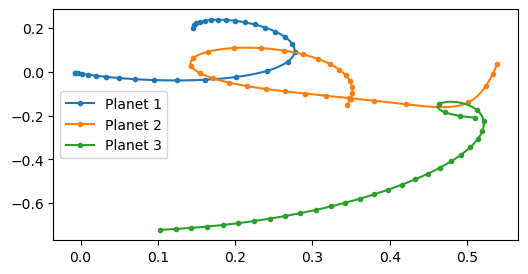

In [9]:
fig, ax = plt.subplots(1, 1, figsize=(6, 3))
for i_planet in range(n):
    ax.plot(*r_t[:, i_planet, :2].T, '.-', markevery=100, 
            label=f'Planet {i_planet+1}')
ax.legend()

# Using the trained models to simulate

In [10]:
tau, n, m, r, v = initvalues_util.initValues(num_bodies, equal_mass=equal_masses)

r_t_preds = [r]
v_t_preds = [v]
m = np.array(m)
start = time.time()
for k in range(num_pred_steps_to_plot):
    rv = np.column_stack([r, v])
    
    rv1 = tc.do_step_wrapper_normal(tau, n, m, rv, model = trained_model)[0]
    r1, v1 = np.split(rv1, indices_or_sections=2, axis=-1)

    r_t_preds.append(r1)
    v_t_preds.append(v1)
    r = copy.deepcopy(r1)
    v = copy.deepcopy(v1)

r_t_preds = np.stack(r_t_preds)
v_t_preds = np.stack(v_t_preds)

(<Figure size 1200x300 with 2 Axes>,
 (<Axes: title={'center': 'True Trajectories'}>,
  <Axes: title={'center': 'Predicted Trajectories'}>))

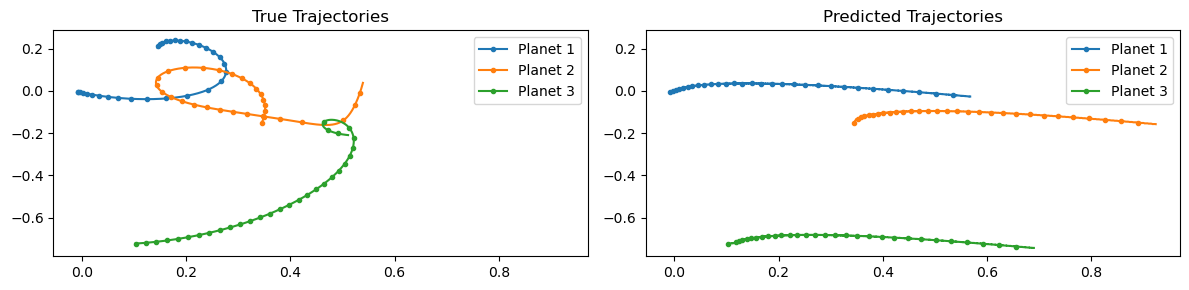

In [11]:
plot.plot_trajectory_comparison(actual_data=r_t, predicted_data=r_t_preds, n=n, filepath=filepath, starting_point=0, num_steps=num_pred_steps_to_plot, savefig=savefig, sub_name=sub_name)

(<Figure size 1000x1200 with 3 Axes>,
 array([<Axes: title={'center': 'Planet 1 Trajectory'}, xlabel='X Position', ylabel='Y Position'>,
        <Axes: title={'center': 'Planet 2 Trajectory'}, xlabel='X Position', ylabel='Y Position'>,
        <Axes: title={'center': 'Planet 3 Trajectory'}, xlabel='X Position', ylabel='Y Position'>],
       dtype=object))

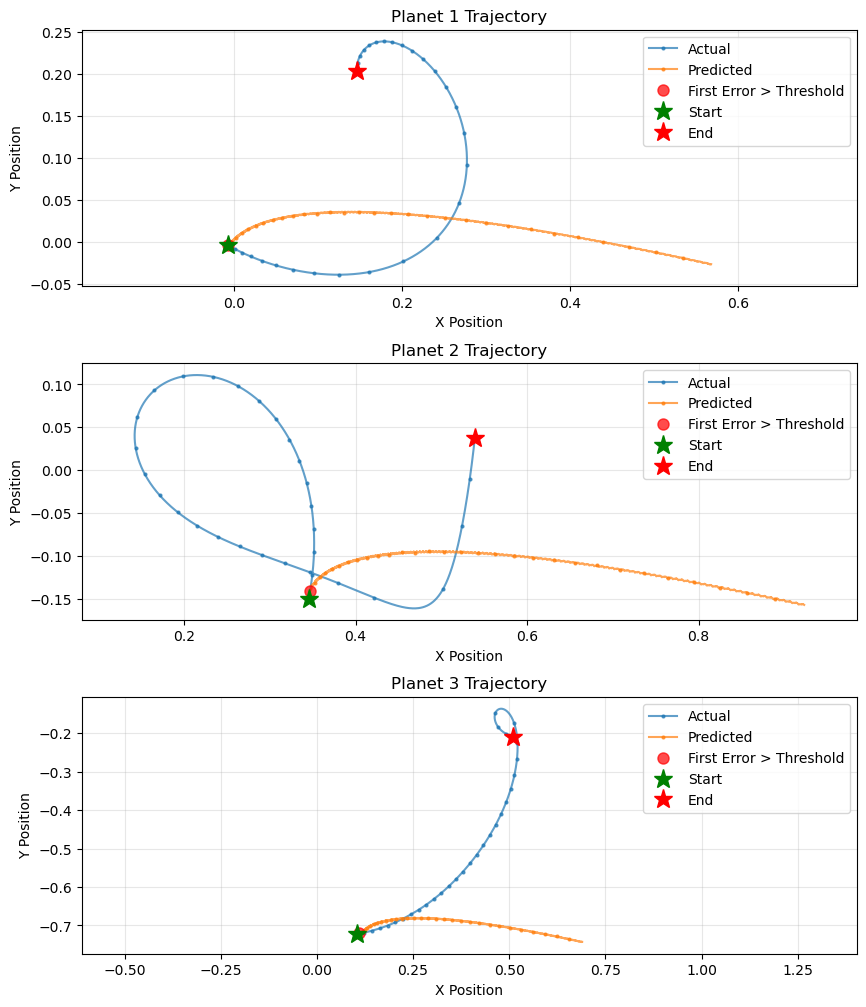

In [12]:
plot.plot_planetary_trajectories(r_t, r_t_preds, filepath, starting_point=0, num_steps=num_pred_steps_to_plot, savefig=savefig, error_threshold=1e-10, markevery=100, sub_name=sub_name)

(<Figure size 1500x500 with 6 Axes>,
 [<Axes3D: title={'center': 'Body 1'}, xlabel='Distance to Body 2', ylabel='Distance to Body 3', zlabel='MSE'>,
  <Axes3D: title={'center': 'Body 2'}, xlabel='Distance to Body 1', ylabel='Distance to Body 3', zlabel='MSE'>,
  <Axes3D: title={'center': 'Body 3'}, xlabel='Distance to Body 1', ylabel='Distance to Body 2', zlabel='MSE'>])

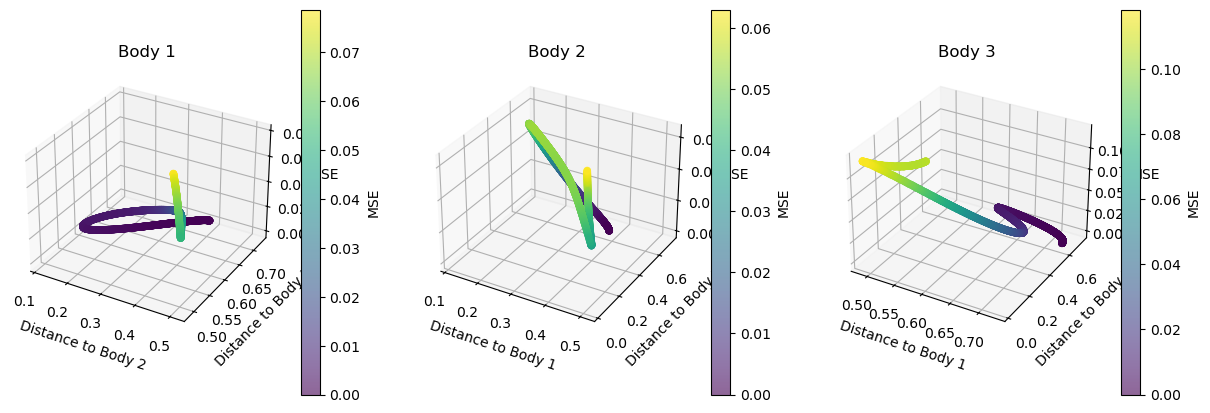

In [13]:
plot.plot_distance_vs_mse(r_t, r_t_preds, filepath, num_steps=num_pred_steps_to_plot, savefig=savefig, sub_name=sub_name)

(<Figure size 1200x1200 with 3 Axes>,
 array([<Axes: title={'center': 'Pointwise MSE for Body 1'}, ylabel='Pointwise MSE'>,
        <Axes: title={'center': 'Pointwise MSE for Body 2'}, ylabel='Pointwise MSE'>,
        <Axes: title={'center': 'Pointwise MSE for Body 3'}, ylabel='Pointwise MSE'>],
       dtype=object))

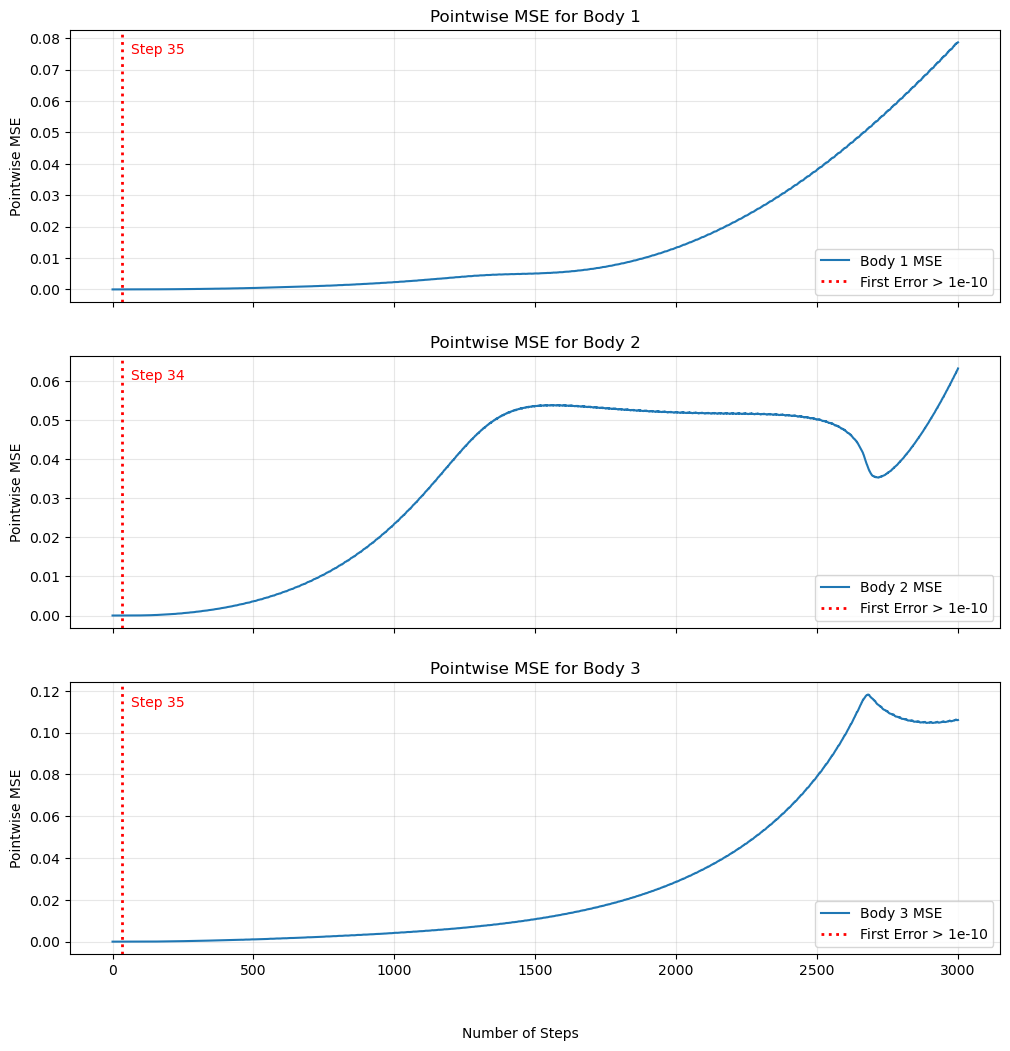

In [14]:
plot.plot_pointwise_mse(r_t, r_t_preds, filepath, sub_name = sub_name, num_steps=num_pred_steps_to_plot+1, savefig=savefig, error_threshold=1e-10)

(<Figure size 800x430 with 6 Axes>,
 array([[<Axes: xlabel='r_out[0]'>, <Axes: xlabel='r_out[1]'>,
         <Axes: xlabel='r_out[2]'>],
        [<Axes: xlabel='v_out[0]'>, <Axes: xlabel='v_out[1]'>,
         <Axes: xlabel='v_out[2]'>]], dtype=object))

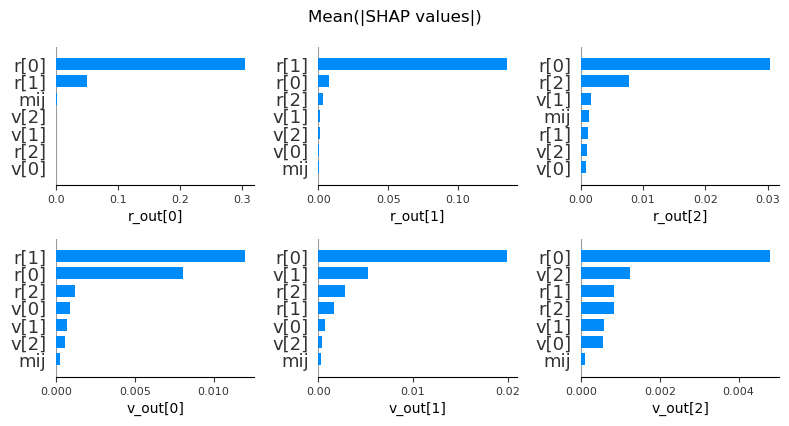

In [15]:
if model_type in ['RF', 'DT']:
    explainer = shap.TreeExplainer(trained_model)
else:
    background = all_kepler_data[np.random.choice(all_kepler_data.shape[0], 100, replace=False)]
    # print(background.shape)
    explainer = shap.KernelExplainer(trained_model, background[:, :7])

plot.plot_SHAP_values(explainer=explainer, data_input=all_kepler_data[:100,:7], filepath=filepath, sub_name=sub_name, savefig = False, title = f"Mean(|SHAP values|)")